In [1]:
import pandas as pd
import missingno as msno
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
color_map = {
    'S1':   (0.25, 0.85, 0.35),   # verde vibrante
    'S2':  (0.85, 0.25, 0.35),   # vermelho vibrante
    'S3': (0.25, 0.25, 0.85),    # azul vibrante
}

scenarios = ['S1', 'S2', 'S3']

map_scenarios = {
    'S1': '$Sce_1$',
    'S2': '$Sce_2$',
    'S3': '$Sce_3$',
}

map_mr = {
    'S1': '10',
    'S2': '7.5',
    'S3': '6.0',
}

map_mechanisms = {
    'S1': {'index_0': 'MAR', 'index_1': 'MCAR', 'index_2': 'MNAR'},
    'S2': {'index_0': 'MAR', 'index_1': 'MNAR', 'index_2': 'MAR', 'index_3': 'MNAR', 'index_4': 'MAR'},
    'S3': {'index_0': 'MNAR', 'index_1': 'MAR', 'index_2': 'MNAR', 'index_3': 'MAR', 'index_4': 'MNAR'},
}

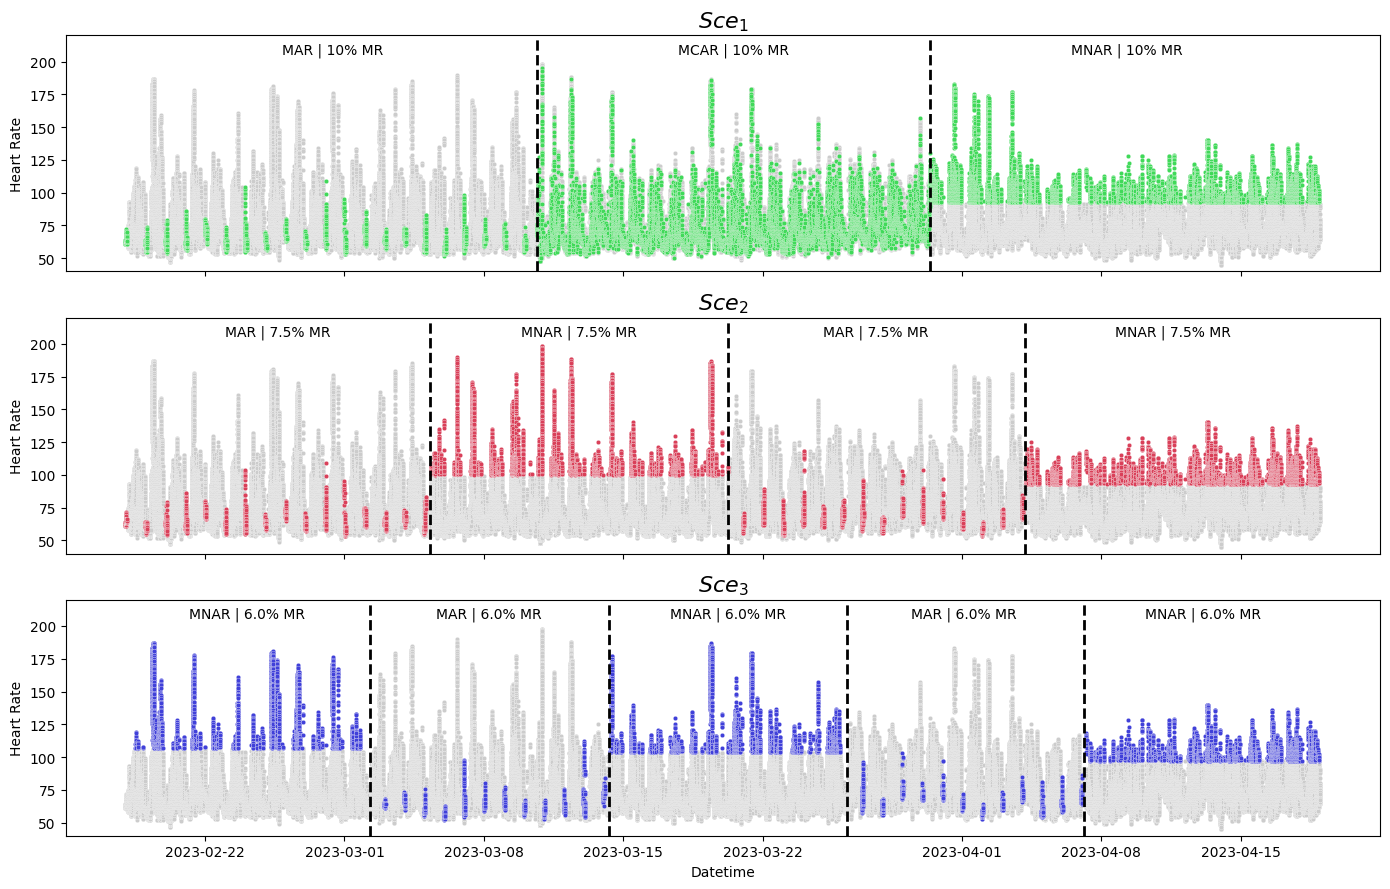

In [3]:
patient_id = 'AAXAA7Z'

df_mec = {}
for mec in ['S1', 'S2', 'S3']:
    df_mec[mec] = [pd.read_csv(os.path.join(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'), f)) 
                   for f in sorted(os.listdir(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'))) if f.endswith('.csv')]

fig, axes = plt.subplots(
    nrows=len(scenarios),
    ncols=1,
    figsize=(14, 9),
    sharex=True
)

for ax, mec in zip(axes, scenarios):

    # 🔵 Ler summary do cenário
    df_sum = pd.read_csv(
        os.path.join('..', 'Data', 'COVID-19-Wearables-MMD',
                     f'summary_{mec}_{30}.csv')
    )

    row_summary = df_sum[
        (df_sum["file_id"] == patient_id) &
        (df_sum["dataset_iteration"] == 1)
    ]

    split_cols = [c for c in row_summary.columns if c.startswith("index_")]

    splits = row_summary[split_cols].values.flatten()
    splits = splits[~pd.isna(splits)].astype(int)
    splits = sorted(splits)

    df_ref = df_mec[mec][0]
    dt_ref = pd.to_datetime(df_ref["datetime"])

    mechanisms = map_mechanisms.get(mec, {})

    for i in range(len(splits) - 1):
        mech_label = mechanisms.get(f"index_{i}")
        if mech_label is None:
            continue

        left = int(splits[i])
        right = int(splits[i + 1])

        if left >= len(dt_ref):
            continue

        mid_idx = (left + min(right, len(dt_ref) - 1)) // 2
        x_mid = dt_ref.iloc[mid_idx]

        ax.text(
            x_mid,
            0.97,
            mech_label + f" | {map_mr.get(mec, 'N/A')}% MR",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=10,
            color="black",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.5),
            zorder=10
        )

    df = df_mec[mec][0].copy()
    df["datetime"] = pd.to_datetime(df["datetime"])

    df["tuple_status"] = df["heartrate"].isna().map({
        True: "Missing",
        False: "Non-missing"
    })

    miss_color = {
        "Missing": color_map[mec],
        "Non-missing": (0.8, 0.8, 0.8)  # cinza claro para os não missing
    }

    df_plot = df[df["heartrate"].isna()]
    df_plot = df.copy()

    # separar dados
    df_non_missing = df_plot[~df_plot["heartrate"].isna()]
    df_missing = df_plot[df_plot["heartrate"].isna()]

    # NORMAL
    sns.scatterplot(
        data=df_non_missing,
        x="datetime",
        y="target",
        ax=ax,
        color=(0.8, 0.8, 0.8),
        linewidth=0.2,
        legend=False,
        s = 10
    )

    # MISSING
    sns.scatterplot(
        data=df_missing,
        x="datetime",
        y="target",
        ax=ax,
        color=color_map[mec],
        linewidth=0.2,
        legend=False,
        s = 10
    )

    ax.set_ylim(40, 220)

    # 🔴 Linhas verticais dos splits
    for split_idx in splits[1:-1]:
        if split_idx < len(df):
            dt = df.iloc[split_idx]["datetime"]
            ax.axvline(
                x=dt,
                color="black",
                linestyle="--",
                linewidth=2,
                # alpha=0.5
            )

    ax.set_title(f"{map_scenarios.get(mec, mec)}", fontsize=16)
    ax.set_ylabel("Heart Rate", fontsize=10)

axes[-1].set_xlabel("Datetime", fontsize=10)

plt.tight_layout()
plt.savefig(f"Plots/scenarios_{patient_id}.png", dpi=300)
plt.show()

In [4]:
def concat_data_all():
    mechanisms = ['S1', 'S2', 'S3', 'S4']
    patients = [p.split('_')[0] for p in os.listdir(os.path.join('..', '..', 'Datasets', 'COVID-19-Wearables')) if p.endswith('_hr.csv')]
 
    dist = {}
    for p in patients:
        if p in ['AJ7TSV9','AS2MVDL']:
            print(f"Skipping patient {p}")
            continue
        for n in range(1,2):
            for miss in ['30']:
                if miss not in dist:
                    dist[miss] = pd.DataFrame()
                for mech in mechanisms:
                    df_sum =  pd.read_csv(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', f'summary_{mech}_{miss}.csv'))
                    row_summary = df_sum[
                        (df_sum["file_id"] == p) &
                        (df_sum["dataset_iteration"] == n)
                    ]
                    split_cols = [col for col in row_summary.columns if col.startswith("index_")]

                    splits = row_summary[split_cols].values.flatten()

                    path = os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mech, p, str(n))
                    df = pd.read_csv(os.path.join(path, f"{p}_hr_{mech}_{n}_{miss}.csv"))

                    nan_mask = df['heartrate'].isna()
                    nan_indices = df[nan_mask].index

                    target_values = df.loc[nan_mask, ['target']].copy()

                    target_values['mechanism'] = mech
                    target_values['miss'] = miss + '%'
                    target_values['patient'] = p

                    # 🔥 Criar coluna split
                    labels = [f"index_{i}" for i in range(len(splits) - 1)]

                    target_values['index'] = pd.cut(
                        nan_indices,
                        bins=splits,
                        labels=labels,
                        right=False
                    )

                    idx_str = target_values['index'].astype(str)
                    mech_map = map_mechanisms.get(mech, {})
                    target_values['mech'] = idx_str.map(mech_map).fillna(idx_str)

                    dist[miss] = pd.concat([dist[miss], target_values], ignore_index=True)

                    df_all = pd.concat([dist[miss] for miss in dist], ignore_index=True)
    return df_all, dist

df_all, df_miss = concat_data_all()

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.